# IndiSignLang: Indian Sign Language Alphabet Recognition with a CNN

**Task:** Multi-class image classification (24 hand-sign classes)
**Approach:** Transfer learning with MobileNetV2 (ImageNet weights)
**Framework:** TensorFlow / Keras, trained on a Google Colab GPU

---

## Project Overview

**Objective.** Build a model that looks at a photo of a hand and tells which Indian Sign Language letter it shows.

**Dataset.** 4,972 images in 24 classes (letters A to Y; J and Z are not in the dataset). Images are stored in one folder per class.

**Workflow in short**

1. Load the data and inspect it: class balance, corrupted files, image sizes, random samples.
2. Build a table of image paths and labels, then split it 70 / 15 / 15 (stratified).
3. Read images through a `tf.data` pipeline and resize them to 224 x 224.
4. Add light augmentation (flip, rotation, zoom) for training.
5. Train a MobileNetV2 classifier: frozen backbone plus a small trainable head.
6. Evaluate on the untouched test set: accuracy, per-class report, confusion matrix, error analysis.
7. Run a single-image prediction.

## Results at a Glance

Every number below is taken from the outputs in this notebook.

| Item | Value |
|---|---|
| Total images | 4,972 |
| Classes | 24 |
| Train / Validation / Test | 3,480 / 746 / 746 |
| Backbone | MobileNetV2, ImageNet weights, frozen |
| Total / trainable parameters | 2,592,088 / 334,104 |
| Training stopped at | Epoch 26 of a maximum 40 (early stopping) |
| Best epoch | 16 |
| Best validation accuracy / loss | 99.60% / 0.0109 |
| **Test accuracy** | **99.46%** (742 of 746 correct) |
| Test loss | 0.0148 |
| Saved model size | 13.01 MB |

## Table of Contents

1. Environment Setup
2. Data Loading
3. Exploratory Data Analysis (EDA)
4. Data Preparation: Labels and Splits
5. Input Pipeline (`tf.data`)
6. Data Augmentation
7. Model Architecture
8. Model Training
9. Training Diagnostics
10. Model Evaluation on the Test Set
11. Error Analysis
12. Inference on a Single Image
13. Conclusion, Limitations and Next Steps

---
## 1. Environment Setup

### 1.1 Import libraries and check hardware

**What it does:** Imports the libraries used in this notebook (NumPy, Pandas, Matplotlib, Seaborn, PIL, TensorFlow / Keras, scikit-learn) and prints the TensorFlow version and the GPUs it can see.

**Why:** Training a CNN on thousands of images is slow on a CPU. Checking for a GPU up front shows straight away if the runtime is set up wrongly. The printed version also helps anyone who wants to reproduce the run.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import tensorflow as tf
from tensorflow.keras import layers, models

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))

TensorFlow: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


**Observation**

- TensorFlow 2.20.0 is used.
- One GPU is detected, so training runs on the GPU.

### 1.2 Mount Google Drive

**What it does:** Connects Google Drive to the Colab runtime.

**Why:** The dataset is stored in Drive as a zip file. Mounting it lets the notebook read the file directly.

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


---
## 2. Data Loading

### 2.1 Set the dataset path

**What it does:** Stores the location of the dataset zip in `zip_path`.

**Why:** Keeping the path in one variable means only one line changes if the file moves.

In [3]:
zip_path = "/content/drive/MyDrive/PRAICP-1000-IndiSignLang.zip"

### 2.2 Extract the dataset

**What it does:** Unzips the archive into `/content/indisignlang_dataset`.

**Why:** Reading thousands of small images from Colab's local disk is generally faster than reading each one from Drive during training.

In [4]:
import zipfile
import os

extract_path = "/content/indisignlang_dataset"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully!")
print("Location:", extract_path)

Dataset extracted successfully!
Location: /content/indisignlang_dataset


---
## 3. Exploratory Data Analysis (EDA)

Before building a model, we check the data: which classes exist, how balanced they are, whether any file is broken, and what the images look like. Problems found here are much cheaper to fix than problems found after training.

### 3.1 Discover the classes

**What it does:** Lists the sub-folders inside `Data/`. Each folder name is one class label.

**Why:** Confirms the folder layout and the number of classes before the rest of the notebook depends on it.

In [5]:
dataset_dir = "/content/indisignlang_dataset/Data"
classes = sorted(os.listdir(dataset_dir))

print("Number of classes:", len(classes))
print("classes:",classes)

Number of classes: 24
classes: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y']


**Observation**

- There are **24 classes**: A to Y.
- The letters **J** and **Z** are not in the class list.

### 3.2 Count images per class

**What it does:** Keeps only folders that contain image files (`.jpg`, `.jpeg`, `.png`, `.bmp`, `.webp`), counts the images in each, and stores the counts in the DataFrame `class_counts_df`.

**Why:** Filtering by file extension stops stray files or empty folders from being counted as classes. These counts feed the balance checks that follow.

In [6]:
image_extensions = (".jpg", ".jpeg", ".png", ".bmp", ".webp")

# Get only folders containing images
classes = []

for cls in os.listdir(dataset_dir):
    class_path = os.path.join(dataset_dir, cls)

    if os.path.isdir(class_path):

        has_image = any(
            file.lower().endswith(image_extensions)
            for file in os.listdir(class_path)
        )

        if has_image:
            classes.append(cls)

# Sort classes
classes = sorted(classes)

print("Number of valid classes:", len(classes))
print("Classes:", classes)


# Count images in each class
class_counts = {}

for cls in classes:
    class_path = os.path.join(dataset_dir, cls)

    count = sum(
        1
        for file in os.listdir(class_path)
        if file.lower().endswith(image_extensions)
    )

    class_counts[cls] = count


# Create DataFrame
class_counts_df = pd.DataFrame(
    list(class_counts.items()),
    columns=["Class", "Image_Count"]
)

class_counts_df.head()

Number of valid classes: 24
Classes: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y']


,Class,Image_Count
0,A,242
1,B,259
2,C,247
3,D,147
4,E,243


**Observation**

- All folders pass the check: 24 valid classes, the same as in 3.1.
- The first five classes show: A = 242, B = 259, C = 247, D = 147, E = 243. Class D is already noticeably smaller than its neighbours.

### 3.3 Dataset statistics

**What it does:** Prints the total number of images and the minimum, maximum and average images per class.

**Why:** A quick numeric check of dataset size and balance.

In [7]:
print("Total images:", class_counts_df["Image_Count"].sum())
print("Number of genders:", len(class_counts_df))
print("Minimum images:", class_counts_df["Image_Count"].min())
print("Maximum images:", class_counts_df["Image_Count"].max())
print("Average images:", class_counts_df["Image_Count"].mean())

Total images: 4972
Number of genders: 24
Minimum images: 116
Maximum images: 259
Average images: 207.16666666666666


**Observation**

| Statistic | Value |
|---|---|
| Total images | 4,972 |
| Number of classes | 24 |
| Minimum per class | 116 |
| Maximum per class | 259 |
| Average per class | 207.17 |

- The largest class has about 2.2 times as many images as the smallest (259 vs 116). That is a moderate imbalance, not an extreme one.
- The line printed as "Number of genders" is the number of classes (24).

### 3.4 Check for corrupted images

**What it does:** Opens every image with PIL and calls `verify()`. Any file that fails is added to `corrupted_images`.

**Why:** One unreadable file can crash training in the middle of an epoch. Checking first is cheap insurance.

In [8]:
corrupted_images = []

for cls in classes:
    class_path = os.path.join(dataset_dir, cls)

    for image_name in os.listdir(class_path):

        if not image_name.lower().endswith(image_extensions):
            continue

        image_path = os.path.join(class_path, image_name)

        try:
            with Image.open(image_path) as img:
                img.verify()

        except Exception:
            corrupted_images.append(image_path)

print("Corrupted images:", len(corrupted_images))

if corrupted_images:
    print("\nExamples:")
    for path in corrupted_images[:10]:
        print(path)

Corrupted images: 0


**Observation**

- **0 corrupted images.** Every image passed, so no files need to be removed.

### 3.5 Class distribution plot

**What it does:** Draws a bar chart of the number of images per class.

**Why:** A chart makes imbalance easier to spot than a table of numbers.

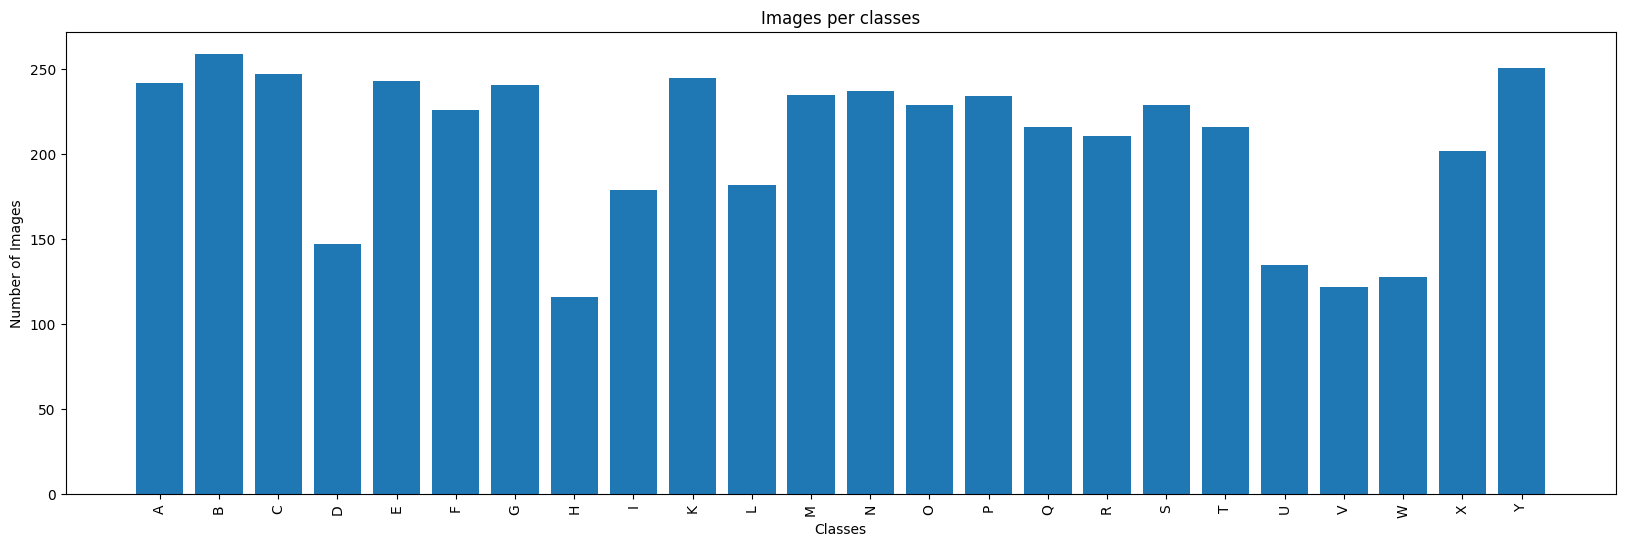

In [9]:
plt.figure(figsize=(20, 6))

plt.bar(
    class_counts_df["Class"],
    class_counts_df["Image_Count"]
)

plt.xticks(rotation=90)
plt.xlabel("Classes")
plt.ylabel("Number of Images")
plt.title("Images per classes")

plt.show()

**Observation**

- Most classes have roughly 200 to 260 images.
- **H is the smallest class (116 images).** V, W, U and D are also clearly below the rest, at roughly 120 to 150 images (read from the chart).
- **B is the largest class (259 images).**
- The imbalance is mild. No resampling or class weights are used in this notebook. Section 10 shows how the smaller classes actually performed.

### 3.6 Look at random samples

**What it does:** Picks 12 random images from random classes and plots them with their labels.

**Why:** Numbers cannot tell us whether labels are correct or whether the images are usable. A visual check confirms that the folder name matches the sign shown and shows what the model will actually see.

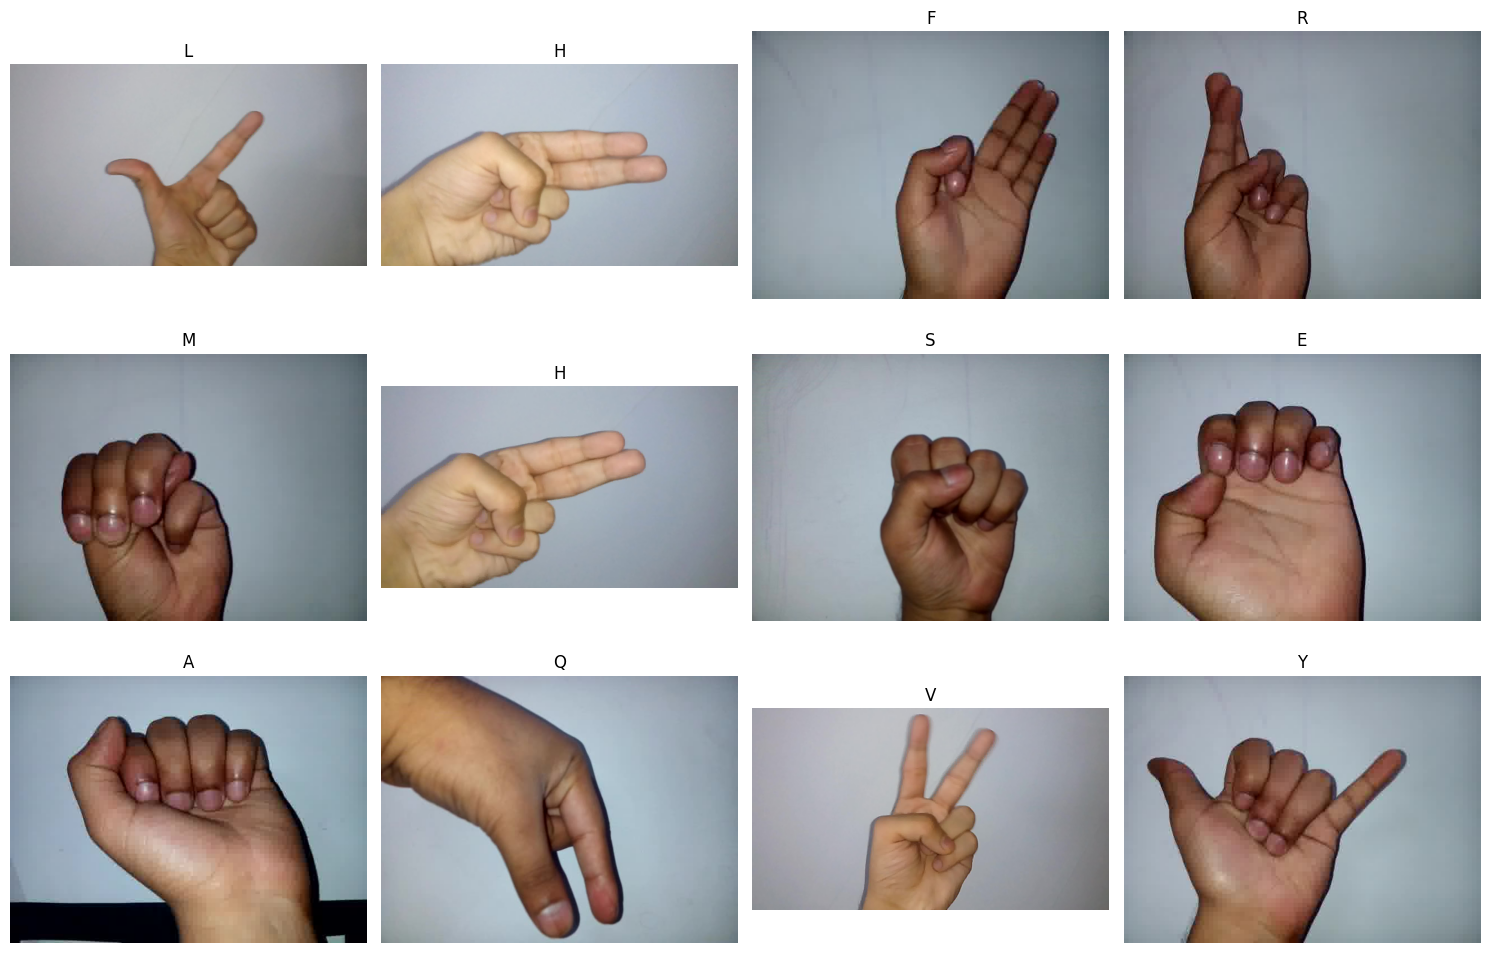

In [10]:
import random
from PIL import Image

plt.figure(figsize=(15, 10))

for i in range(12):
    classs = random.choice(classes)
    classs_path = os.path.join(dataset_dir, classs)

    images = [
        f for f in os.listdir(classs_path)
        if f.lower().endswith(image_extensions)
    ]

    image_name = random.choice(images)
    image_path = os.path.join(classs_path, image_name)

    image = Image.open(image_path)

    plt.subplot(3, 4, i + 1)
    plt.imshow(image)
    plt.title(classs)
    plt.axis("off")

plt.tight_layout()
plt.show()

**Observation**

- Photos are taken against **plain, light grey-blue backgrounds** with little clutter.
- The hand fills a large part of the frame.
- Hand size, skin tone and orientation vary between samples, and so does the image shape (some wider, some taller).

### 3.7 Check image sizes

**What it does:** Reads the width and height of the first 20 images in each class (480 images in total) and summarises them with `describe()`.

**Why:** A CNN needs one fixed input size. Knowing the range of original sizes shows how much resizing is needed. Only a sample is read to keep the check fast.

In [11]:
sizes = []

for cls in classes:
    class_path = os.path.join(dataset_dir, cls)

    images = [
        f for f in os.listdir(class_path)
        if f.lower().endswith(image_extensions)
    ]

    for image_name in images[:20]:
        image_path = os.path.join(class_path, image_name)

        try:
            with Image.open(image_path) as img:
                sizes.append(img.size)
        except:
            pass

sizes_df = pd.DataFrame(sizes, columns=["Width", "Height"])

sizes_df.describe()

,Width,Height
count,480.000000,480.000000
mean,978.666667,692.000000
std,551.271877,366.266955
min,640.000000,480.000000
25%,640.000000,480.000000
50%,640.000000,480.000000
75%,1296.000000,1088.000000
max,1920.000000,1920.000000


**Observation**

- The smallest images are 640 x 480, and the **median image is also 640 x 480**.
- The upper quartile is 1296 x 1088, and the maximum width and height are both 1920.
- Mean size is about 979 x 692.
- So the dataset **mixes at least two different resolutions**. All images must be resized to one common size, which is done in Section 5.
- These figures come from a sample of 480 images, not the full set.

---
## 4. Data Preparation: Labels and Splits

### 4.1 Build a DataFrame of image paths

**What it does:** Loops over every class folder and stores each image's full path and class name in the DataFrame `df`.

**Why:** A table of (path, label) rows makes splitting simple. It also lets us load images only when needed, instead of holding thousands of decoded images in memory.

In [12]:
import os
import pandas as pd

image_extensions = (".jpg", ".jpeg", ".png", ".bmp", ".webp")

data = []

for cls in classes:
    class_path = os.path.join(dataset_dir, cls)

    for file in os.listdir(class_path):

        if file.lower().endswith(image_extensions):

            image_path = os.path.join(class_path, file)

            data.append({
                "image_path": image_path,
                "classes": cls
            })

df = pd.DataFrame(data)

print("Total images:", len(df))
print("Total classes:", df["classes"].nunique())

df.head()

Total images: 4972
Total classes: 24


,image_path,classes
0,/content/indisignlang_dataset/Data/A/237.jpg,A
1,/content/indisignlang_dataset/Data/A/227.jpg,A
2,/content/indisignlang_dataset/Data/A/031.jpg,A
3,/content/indisignlang_dataset/Data/A/139.jpg,A
4,/content/indisignlang_dataset/Data/A/030.jpg,A


**Observation**

- `df` has **4,972 rows** and **24 classes**, matching the counts from the EDA.
- The first rows are images from class A, as expected from the folder order.

### 4.2 Create integer labels

**What it does:** Sorts the class names and builds two dictionaries: `class_to_index` (letter to number) and `index_to_class` (number to letter).

**Why:** Neural networks need numeric targets. Sorting makes the mapping the same on every run. The reverse dictionary turns predictions back into letters later.

In [13]:
classes = sorted(df["classes"].unique())

class_to_index = {
    classes: index
    for index, classes in enumerate(classes)
}

index_to_class = {
    index: classes
    for classes, index in class_to_index.items()
}

### 4.3 Verify the label mapping

**What it does:** Prints the number of classes and every index-to-letter pair.

**Why:** Catches ordering or off-by-one mistakes before they affect training.

In [14]:
print("Number of classes:", len(classes))

print("\n mappings:")
for i in range(len(classes)):
    print(i, "→", index_to_class[i])

Number of classes: 24

 mappings:
0 → A
1 → B
2 → C
3 → D
4 → E
5 → F
6 → G
7 → H
8 → I
9 → K
10 → L
11 → M
12 → N
13 → O
14 → P
15 → Q
16 → R
17 → S
18 → T
19 → U
20 → V
21 → W
22 → X
23 → Y


**Observation**

- 24 classes are mapped to integers **0 to 23** in alphabetical order (A = 0 ... Y = 23).
- Because J is missing, the numbering goes straight from I (8) to K (9).

### 4.4 Attach numeric labels to the DataFrame

**What it does:** Adds a `label` column to `df` by mapping each class name through `class_to_index`.

**Why:** The loss function used later (`sparse_categorical_crossentropy`) expects integer labels.

In [15]:
df["label"] = df["classes"].map(class_to_index)

In [16]:
df.head()

,image_path,classes,label
0,/content/indisignlang_dataset/Data/A/237.jpg,A,0
1,/content/indisignlang_dataset/Data/A/227.jpg,A,0
2,/content/indisignlang_dataset/Data/A/031.jpg,A,0
3,/content/indisignlang_dataset/Data/A/139.jpg,A,0
4,/content/indisignlang_dataset/Data/A/030.jpg,A,0


**Observation**

- The new `label` column is in place. Rows from class A carry label 0.

### 4.5 Train / validation / test split

**What it does:** Splits the data in two steps with `random_state=42`. First 70% goes to training. The remaining 30% is then divided in half: 15% validation and 15% test.

**Why:**

- **Train** set: the model learns from it.
- **Validation** set: used to watch progress and to decide when to stop training.
- **Test** set: kept aside until the end for an unbiased final score.
- `stratify` on the label keeps the class proportions the same in all three subsets. This matters here because class sizes range from 116 to 259 images.
- The fixed seed gives the same split on every run.

In [17]:
train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    stratify=df["label"],
    random_state=42
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["label"],
    random_state=42
)

### 4.6 Check split sizes

In [18]:
print("Training:", len(train_df))
print("Validation:", len(val_df))
print("Testing:", len(test_df))

Training: 3480
Validation: 746
Testing: 746


**Observation**

| Split | Images | Share |
|---|---|---|
| Training | 3,480 | about 70% |
| Validation | 746 | about 15% |
| Test | 746 | about 15% |

The three parts add up to 4,972, the full dataset.

### 4.7 Confirm every class is in every split

**What it does:** Counts the unique classes in each split.

**Why:** Stratification should guarantee this. A quick check makes sure no class is missing from validation or test.

In [19]:
print("Train classes:", train_df["classes"].nunique())
print("Validation classes:", val_df["classes"].nunique())
print("Test classes:", test_df["classes"].nunique())

Train classes: 24
Validation classes: 24
Test classes: 24


**Observation**

- Training, validation and test each contain **all 24 classes**.

In [20]:
train_df.head(10)

,image_path,classes,label
998,/content/indisignlang_dataset/Data/E/081.jpg,E,4
1952,/content/indisignlang_dataset/Data/K/037.jpg,K,9
4406,/content/indisignlang_dataset/Data/W/076.jpg,W,21
4023,/content/indisignlang_dataset/Data/T/141.jpg,T,18
4817,/content/indisignlang_dataset/Data/Y/225.jpg,Y,23
60,/content/indisignlang_dataset/Data/A/101.jpg,A,0
4823,/content/indisignlang_dataset/Data/Y/217.jpg,Y,23
1073,/content/indisignlang_dataset/Data/E/097.jpg,E,4
1953,/content/indisignlang_dataset/Data/K/039.jpg,K,9
3886,/content/indisignlang_dataset/Data/S/005.jpg,S,17


**Observation**

- The first rows of `train_df` show classes in mixed order (E, K, W, T, Y, A ...), so the data was shuffled during the split.

---
## 5. Input Pipeline (`tf.data`)

Instead of loading every image into memory, a `tf.data` pipeline reads and prepares images in batches while training runs.

### 5.1 Set global parameters

**What it does:** Sets `SEED = 42`, `IMG_SIZE = (224, 224)` and `BATCH_SIZE = 16`.

**Why:**

- **224 x 224** is the input size MobileNetV2 was designed and pretrained for.
- **Batch size 16** keeps GPU memory use low.
- Keeping these values in one place means a change is made once.

In [21]:
SEED = 42
IMG_SIZE = (224, 224)
BATCH_SIZE = 16

### 5.2 Create dataset objects

**What it does:** Builds one `tf.data.Dataset` each for train, validation and test from (image path, label) pairs.

**Why:** These datasets hand the images to the model one batch at a time.

In [22]:
train_dataset = tf.data.Dataset.from_tensor_slices(
    (
        train_df["image_path"].values,
        train_df["label"].values
    )
)

val_dataset = tf.data.Dataset.from_tensor_slices(
    (
        val_df["image_path"].values,
        val_df["label"].values
    )
)

test_dataset = tf.data.Dataset.from_tensor_slices(
    (
        test_df["image_path"].values,
        test_df["label"].values
    )
)


### 5.3 Define the image-loading function

**What it does:** `load_image` reads a file, decodes the JPEG as 3-channel RGB, resizes it to 224 x 224 and casts it to `float32`.

**Why:** It turns a file path into a tensor the model accepts. Forcing 3 channels guards against greyscale files. Pixel values stay in the 0 to 255 range here because scaling is done inside the model (see 7.2).

**Note:** `tf.image.resize` stretches each image to 224 x 224 without keeping the aspect ratio. Many originals are 4:3 (640 x 480), so they are slightly squeezed.

In [23]:
def load_image(image_path, label):
    image = tf.io.read_file(image_path)

    image = tf.image.decode_jpeg(
        image,
        channels=3
    )

    image = tf.image.resize(
        image,
        IMG_SIZE
    )

    image = tf.cast(
        image,
        tf.float32

    )

    return image, label


### 5.4 Apply the loader to all three datasets

**What it does:** Maps `load_image` over train, validation and test with `num_parallel_calls=tf.data.AUTOTUNE`.

**Why:** Images are read and resized in parallel, so the GPU spends less time waiting for data.

In [24]:
train_dataset = train_dataset.map(
    load_image,
    num_parallel_calls=tf.data.AUTOTUNE
)
1
val_dataset = val_dataset.map(
    load_image,
    num_parallel_calls=tf.data.AUTOTUNE
)

test_dataset = test_dataset.map(
    load_image,
    num_parallel_calls=tf.data.AUTOTUNE
)

### 5.5 Shuffle and batch

**What it does:** Shuffles the training set with a buffer of 1,000 (seeded) and groups all three sets into batches of 16. Validation and test are batched but not shuffled.

**Why:** Shuffling the training data stops the model from picking up the order of the files. Validation and test stay unshuffled so evaluation is repeatable.

In [25]:
train_dataset = train_dataset.shuffle(
    1000,
    seed=SEED
).batch(BATCH_SIZE)

val_dataset = val_dataset.batch(BATCH_SIZE)

test_dataset = test_dataset.batch(BATCH_SIZE)

### 5.6 Sanity-check one batch

**What it does:** Pulls one batch from the training set and prints its shapes and data types.

**Why:** Confirms the pipeline output matches what the model expects before any training starts.

In [26]:
for images, labels in train_dataset.take(1):
    print("Images shape:", images.shape)
    print("Labels shape:", labels.shape)
    print("Image dtype:", images.dtype)
    print("Labels dtype:", labels.dtype)

Images shape: (16, 224, 224, 3)
Labels shape: (16,)
Image dtype: <dtype: 'float32'>
Labels dtype: <dtype: 'int64'>


**Observation**

- Images: `(16, 224, 224, 3)`, `float32`. That is a batch of 16 RGB images at 224 x 224.
- Labels: `(16,)`, `int64`. One integer label per image.
- Both match the model's expected input.

### 5.7 Visualise a training batch

**What it does:** Plots the 16 images of one training batch. The images are cast to `uint8` only for display.

**Why:** Confirms that resizing did not damage the images or their colours.

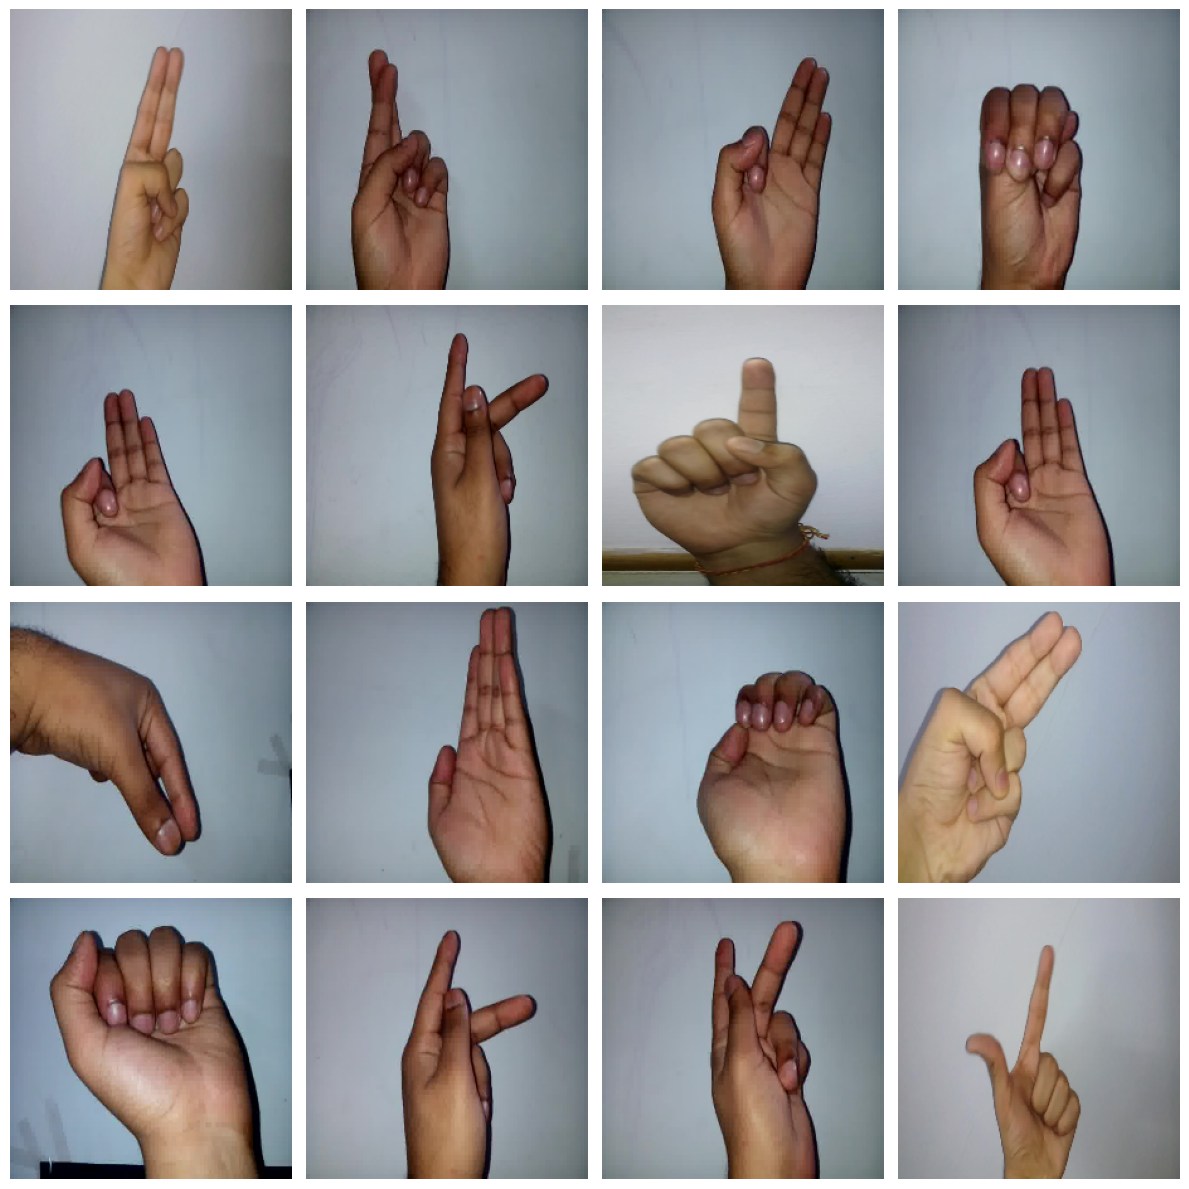

In [27]:
import matplotlib.pyplot as plt

for images, labels in train_dataset.take(1):

    plt.figure(figsize=(12, 12))

    for i in range(16):
        plt.subplot(4, 4, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.axis("off")

    plt.tight_layout()
    plt.show()

**Observation**

- Hands are clearly visible and colours look natural after resizing.
- Backgrounds are plain, as seen in the raw samples.
- The images are now square, so the 4:3 originals show a mild stretch, but the signs remain easy to recognise.

---
## 6. Data Augmentation

### 6.1 Define the augmentation layers

**What it does:** Builds a small Keras `Sequential` block with three random transforms:

| Layer | Setting | Effect |
|---|---|---|
| `RandomFlip` | horizontal | Mirrors the image |
| `RandomRotation` | 0.1 | Rotates by up to 10% of a full turn (about 36 degrees either way) |
| `RandomZoom` | 0.1 | Zooms in or out by up to 10% |

**Why:** With about 3,500 training images, augmentation shows the model slightly different versions of each photo every epoch. This makes it harder to memorise the training set. These layers only act during training. They are switched off for validation, testing and prediction.

**Note:** A horizontal flip gives the mirror-image hand. The notebook does not run an experiment without flipping, so the exact effect of this choice is not measured.

In [28]:
data_augmentation = tf.keras.Sequential([    #Augmentation increases the variety of training data, not necessarily the number of dataset samples.
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1)
])

### 6.2 Preview augmented images

**What it does:** Applies the augmentation to one training batch and plots the result.

**Why:** Checks that the transforms are realistic and the signs still look like the same sign.

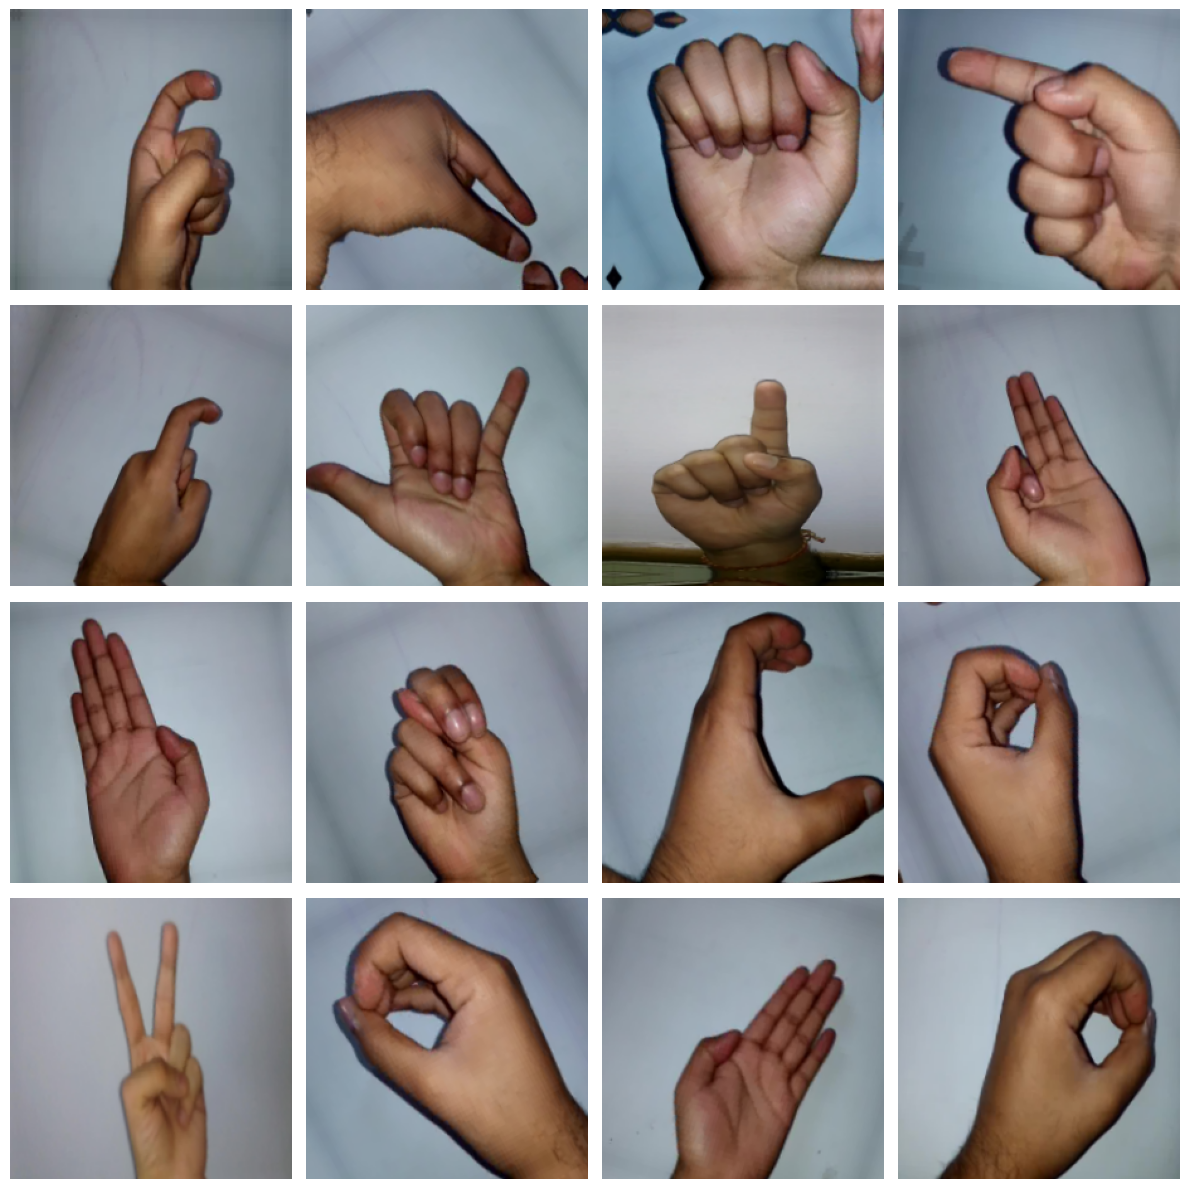

In [29]:
import matplotlib.pyplot as plt

for images, labels in train_dataset.take(1):

    augmented_images = data_augmentation(images)

    plt.figure(figsize=(12, 12))

    for i in range(16):
        plt.subplot(4, 4, i + 1)
        plt.imshow(augmented_images[i].numpy().astype("uint8"))
        plt.axis("off")

    plt.tight_layout()
    plt.show()

**Observation**

- Images show mild tilts and zooms, and the hand shape stays recognisable.
- Some samples have small edge artefacts (pieces of fingers or background repeated near the corners), which come from the fill used after rotation and zoom.

---
## 7. Model Architecture

### 7.1 Load the pretrained backbone (MobileNetV2)

**What it does:** Loads MobileNetV2 with ImageNet weights and `include_top=False`, which removes the original 1,000-class output layer. Then `base_model.trainable = False` freezes it.

**Why (transfer learning):**

- Training a CNN from scratch on about 3,500 images would be slower and more prone to overfitting. MobileNetV2 has already learned general visual features (edges, textures, shapes) from ImageNet.
- MobileNetV2 is small and fast, which suits a compact model.
- Freezing keeps the pretrained features unchanged, so only the new layers on top are trained.

In [30]:
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet"
)

base_model.trainable = False

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


**Observation**

- The ImageNet weights file (no top layer, about 9 MB) was downloaded.

### 7.2 Assemble the full classifier

**What it does:** Stacks the layers into one `Sequential` model:

| Layer | Purpose |
|---|---|
| `Input (224, 224, 3)` | RGB image |
| `data_augmentation` | Random flip / rotation / zoom (training only) |
| `Lambda(preprocess_input)` | Scales pixel values the way MobileNetV2 expects |
| `MobileNetV2` (frozen) | Extracts features, output `(7, 7, 1280)` |
| `GlobalAveragePooling2D` | Reduces each feature map to one number, giving 1,280 features |
| `Dense(256, relu)` | Learns letter-specific combinations of those features |
| `Dropout(0.3)` | Randomly drops 30% of units during training to reduce overfitting |
| `Dense(24, softmax)` | Outputs one probability per class |

**Why:** Augmentation and preprocessing sit inside the model, so the saved model accepts raw 0 to 255 images and needs no separate preprocessing code at prediction time.

In [31]:
mobilenet_model = tf.keras.Sequential([

    tf.keras.layers.Input(
        shape=(224, 224, 3)
    ),

    data_augmentation,

    tf.keras.layers.Lambda(
        tf.keras.applications.mobilenet_v2.preprocess_input
    ),

    base_model,

    tf.keras.layers.GlobalAveragePooling2D(),

    tf.keras.layers.Dense(
        256,
        activation="relu"
    ),

    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.Dense(
        24,
        activation="softmax"
    )
])
mobilenet_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda (Lambda)                 │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 24)             │         6,168 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,592,088 (9.89 MB)

 Trainable params: 334,104 (1.27 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

**Observation**

| Parameters | Count | Size |
|---|---|---|
| Total | 2,592,088 | 9.89 MB |
| Trainable | 334,104 | 1.27 MB |
| Non-trainable | 2,257,984 | 8.61 MB |

- Only about **12.9%** of the parameters are trained. They belong to the two Dense layers (327,936 + 6,168).
- The 2,257,984 frozen parameters are the MobileNetV2 backbone.
- The final layer outputs 24 values, one per class.

### 7.3 Compile the model

**What it does:** Sets the optimiser to Adam (learning rate 0.001), the loss to `sparse_categorical_crossentropy` and the metric to accuracy.

**Why:**

- **Adam** is a dependable default optimiser for this kind of model.
- **Sparse** categorical cross-entropy is used because labels are plain integers (0 to 23), not one-hot vectors.
- **Accuracy** is easy to read for a multi-class problem with fairly balanced classes.

In [32]:
mobilenet_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),
    loss="sparse_categorical_crossentropy",       #We use SparseCategoricalCrossentropy because your labels are integers
    metrics=["accuracy"]
)

### 7.4 Configure early stopping

**What it does:** Watches `val_loss` and stops training if it has not improved for 10 epochs in a row (`patience=10`). With `restore_best_weights=True`, the model goes back to its best epoch when training ends.

**Why:** Saves time, limits overfitting, and makes sure the final model is the best one, not simply the last one.

In [33]:
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

---
## 8. Model Training

### 8.1 Train the model

**What it does:** Calls `fit` on the training set and checks the validation set after every epoch. The limit is 40 epochs, with early stopping active.

**Why:** 40 is only a ceiling. Early stopping decides how many epochs are actually needed.

In [34]:
history = mobilenet_model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=40,
    callbacks=[early_stopping]
)

Epoch 1/40
218/218 ━━━━━━━━━━━━━━━━━━━━ 25s 68ms/step - accuracy: 0.7859 - loss: 0.7961 - val_accuracy: 0.9383 - val_loss: 0.2236
Epoch 2/40
218/218 ━━━━━━━━━━━━━━━━━━━━ 14s 56ms/step - accuracy: 0.9557 - loss: 0.1616 - val_accuracy: 0.9759 - val_loss: 0.0906
Epoch 3/40
218/218 ━━━━━━━━━━━━━━━━━━━━ 15s 58ms/step - accuracy: 0.9776 - loss: 0.0950 - val_accuracy: 0.9759 - val_loss: 0.0793
Epoch 4/40
218/218 ━━━━━━━━━━━━━━━━━━━━ 19s 53ms/step - accuracy: 0.9773 - loss: 0.0779 - val_accuracy: 0.9826 - val_loss: 0.0639
Epoch 5/40
218/218 ━━━━━━━━━━━━━━━━━━━━ 16s 63ms/step - accuracy: 0.9868 - loss: 0.0498 - val_accuracy: 0.9732 - val_loss: 0.0657
Epoch 6/40
218/218 ━━━━━━━━━━━━━━━━━━━━ 14s 54ms/step - accuracy: 0.9830 - loss: 0.0620 - val_accuracy: 0.9732 - val_loss: 0.0956
Epoch 7/40
218/218 ━━━━━━━━━━━━━━━━━━━━ 13s 52ms/step - accuracy: 0.9897 - loss: 0.0347 - val_accuracy: 0.9853 - val_loss: 0.0404
Epoch 8/40
218/218 ━━━━━━━━━━━━━━━━━━━━ 16s 64ms/step - accuracy: 0.9805 - loss: 0.0592 - 

**Observation**

Selected epochs from the training log:

| Epoch | Train acc | Train loss | Val acc | Val loss |
|---|---|---|---|---|
| 1 | 0.7859 | 0.7961 | 0.9383 | 0.2236 |
| 2 | 0.9557 | 0.1616 | 0.9759 | 0.0906 |
| **16 (best)** | 0.9856 | 0.0458 | **0.9960** | **0.0109** |
| 20 | 0.9937 | 0.0185 | 0.9531 | 0.1353 |
| 24 | 0.9868 | 0.0410 | 0.9544 | 0.1755 |
| 26 (last) | 0.9925 | 0.0225 | 0.9879 | 0.0292 |

- **Fast start:** validation accuracy is already 93.8% after epoch 1 and 97.6% after epoch 2.
- **Early stopping** ended training at epoch 26. The best epoch was 16, and 16 + patience of 10 = 26.
- **Validation is noisy in later epochs.** Between epochs 16 and 26 validation loss moves between 0.0109 and 0.1755, while training accuracy stays in the 98 to 99% range.
- In the first epochs validation accuracy is higher than training accuracy (epoch 1: 93.8% vs 78.6%). This is common: training metrics are averaged over an epoch while the model is still improving, with augmentation and dropout switched on, whereas validation is measured at the end of the epoch with both off.

### 8.2 Find the best epoch

**What it does:** Finds the epoch with the lowest validation loss and prints the validation loss and accuracy at that epoch.

**Why:** Confirms which epoch's weights the final model holds, since `restore_best_weights=True` was used.

In [35]:

best_epoch = np.argmin(history.history["val_loss"]) + 1

print("Best epoch:", best_epoch)
print("Best validation loss:", history.history["val_loss"][best_epoch - 1])
print("Best validation accuracy:", history.history["val_accuracy"][best_epoch - 1])

Best epoch: 16
Best validation loss: 0.010880360379815102
Best validation accuracy: 0.9959785342216492


**Observation**

- Best epoch: **16**.
- Validation loss there: **0.0109**. Validation accuracy: **99.60%**.
- All evaluation below uses the weights from this epoch.

### 8.3 Save the model

**What it does:** Saves the trained model in Keras format (`.keras`) as `40_epoch_indisignlang.keras`.

**Why:** The saved file can be reloaded for prediction or deployment without retraining.

**Note:** The file name reflects the configured limit of 40 epochs. Training actually stopped at epoch 26. The file is written to the Colab runtime's working directory.

In [36]:
mobilenet_model.save("40_epoch_indisignlang.keras")

### 8.4 Check the saved file size

**What it does:** Prints the size of the saved file in MB.

**Why:** Confirms the save worked and shows the deployment footprint.

In [37]:
print(os.path.getsize("40_epoch_indisignlang.keras") / (1024 * 1024), "MB")

13.012850761413574 MB


**Observation**

- The saved model is **13.01 MB**, which is small.

---
## 9. Training Diagnostics

### 9.1 Training vs validation accuracy

**What it does:** Plots training and validation accuracy for every epoch.

**Why:** The curves show how learning progressed and whether training and validation drift apart, which would signal overfitting.

*The x-axis starts at 0, so plot position 0 is Epoch 1 in the log.*

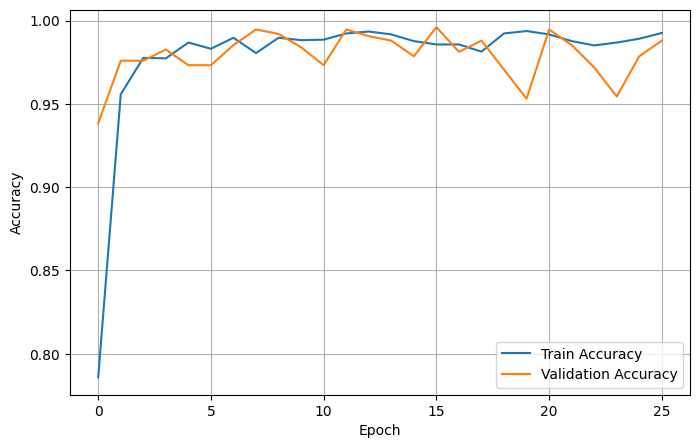

In [38]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid()
plt.show()

**Observation**

- Training accuracy climbs from about 0.79 to about 0.96 in the first two epochs, then levels off around 0.98 to 0.99.
- Validation accuracy stays mostly between 0.97 and 1.00, with two visible dips (Epoch 20 at 0.9531 and Epoch 24 at 0.9544) that recover quickly.
- Validation accuracy sits close to or above training accuracy for most of the run. There is **no sustained gap** with training improving while validation falls, so there is no clear sign of overfitting.

### 9.2 Training vs validation loss

**What it does:** Plots training and validation loss for every epoch.

**Why:** Loss is more sensitive than accuracy, so it shows instability and overfitting earlier.

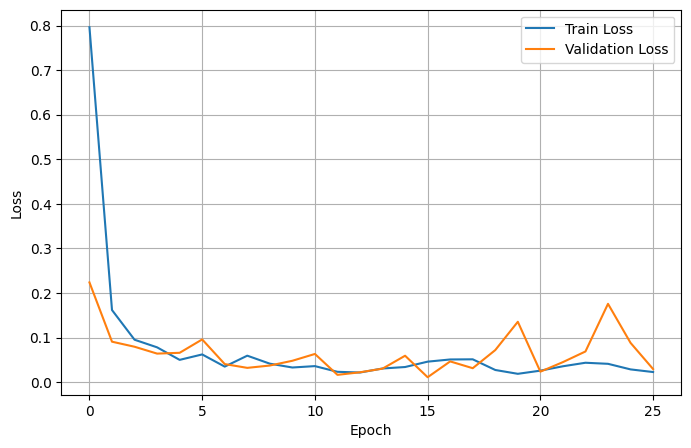

In [39]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid()
plt.show()

**Observation**

- Training loss falls steeply from about 0.80 in Epoch 1 to about 0.16 in Epoch 2, then stays low, mostly between 0.02 and 0.06.
- Validation loss follows the same pattern. Its lowest point is Epoch 16 (0.0109).
- It spikes at Epoch 20 (0.1353) and Epoch 24 (0.1755) and comes back down each time. These are short-lived jumps, not a lasting divergence.
- The spikes show that validation loss is sensitive from epoch to epoch, which is why early stopping with best-weight restore is useful here.

---
## 10. Model Evaluation on the Test Set

The test set was not used for training or for early stopping, so it gives the most honest estimate of performance on new images from this dataset.

### 10.1 Overall test loss and accuracy

**What it does:** Runs `evaluate` on the test dataset.

**Why:** One headline number to compare with the validation results.

In [40]:
test_loss, test_accuracy = mobilenet_model.evaluate(test_dataset)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

47/47 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - accuracy: 0.9946 - loss: 0.0148
Test Loss: 0.014751674607396126
Test Accuracy: 0.9946380853652954


**Observation**

- **Test accuracy: 0.9946 (99.46%).** Test loss: 0.0148.
- On 746 test images this is 742 correct predictions (confirmed in Section 11).
- The result is very close to the validation result at the best epoch (99.60% accuracy, 0.0109 loss). The validation performance carried over to the test set.

### 10.2 Collect true and predicted labels

**What it does:** Loops through the test batches, predicts each one, takes the class with the highest probability (`argmax`), and stores the true and predicted labels in two arrays.

**Why:** scikit-learn's report and the confusion matrix need these two arrays.

In [41]:
y_true = []
y_pred = []

for images, labels in test_dataset:
    predictions = mobilenet_model.predict(images, verbose=0)

    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(predictions, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

print("True labels shape:", y_true.shape)
print("Predicted labels shape:", y_pred.shape)

True labels shape: (746,)
Predicted labels shape: (746,)


**Observation**

- 746 true labels and 746 predictions: one of each per test image.

### 10.3 Recover class names in label order

**What it does:** Builds the list of class names ordered by their integer label.

**Why:** Reports and plots need letters in the same order as the numeric labels.

In [43]:
class_names = (
    train_df.sort_values("label")
    .drop_duplicates("label")["classes"]
    .tolist()
)

print(len(class_names))
print(class_names)

24
['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y']


**Observation**

- 24 names from A to Y (no J), in label order.

### 10.4 Classification report

**What it does:** Prints precision, recall and F1-score for every class.

**Why:** Overall accuracy can hide weak classes. The report shows each class separately.

- **Precision:** of the images predicted as this class, how many were right.
- **Recall:** of the real images of this class, how many were found.
- **F1-score:** the balance of the two.

In [44]:
from sklearn.metrics import classification_report

report = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    zero_division=0
)

print(report)

              precision    recall  f1-score   support

           A       0.97      1.00      0.99        36
           B       1.00      1.00      1.00        39
           C       1.00      1.00      1.00        37
           D       1.00      1.00      1.00        22
           E       1.00      1.00      1.00        36
           F       1.00      1.00      1.00        34
           G       1.00      0.97      0.99        36
           H       1.00      1.00      1.00        17
           I       1.00      1.00      1.00        27
           K       1.00      1.00      1.00        37
           L       1.00      1.00      1.00        28
           M       1.00      1.00      1.00        35
           N       1.00      0.92      0.96        36
           O       1.00      1.00      1.00        34
           P       1.00      1.00      1.00        35
           Q       1.00      1.00      1.00        33
           R       1.00      1.00      1.00        32
           S       1.00    

**Observation**

- Overall accuracy is 0.99 on 746 images. Macro-average precision, recall and F1 all show 1.00 (rounded).
- **20 of 24 classes score 1.00** on precision, recall and F1.
- Four classes score below 1.00:

| Class | Precision | Recall | F1 | Test images |
|---|---|---|---|---|
| A | 0.97 | 1.00 | 0.99 | 36 |
| G | 1.00 | 0.97 | 0.99 | 36 |
| N | 1.00 | 0.92 | 0.96 | 36 |
| T | 0.91 | 1.00 | 0.96 | 32 |

- N recall (0.92) and T precision (0.91) point to the same issue: some N images are predicted as T. A precision (0.97) and G recall (0.97) point to a G image predicted as A. Section 11 confirms both.
- The smallest classes (H 17, V 19, W 19, U 20, D 22 test images) all score 1.00. The class imbalance did not visibly hurt them, though with so few images each, one mistake would have moved the score noticeably.

### 10.5 Confusion matrix

**What it does:** Plots a 24 x 24 heatmap. Rows are the true letters, columns are the predicted letters.

**Why:** The diagonal shows correct predictions. Anything off the diagonal shows exactly which letters get mixed up.

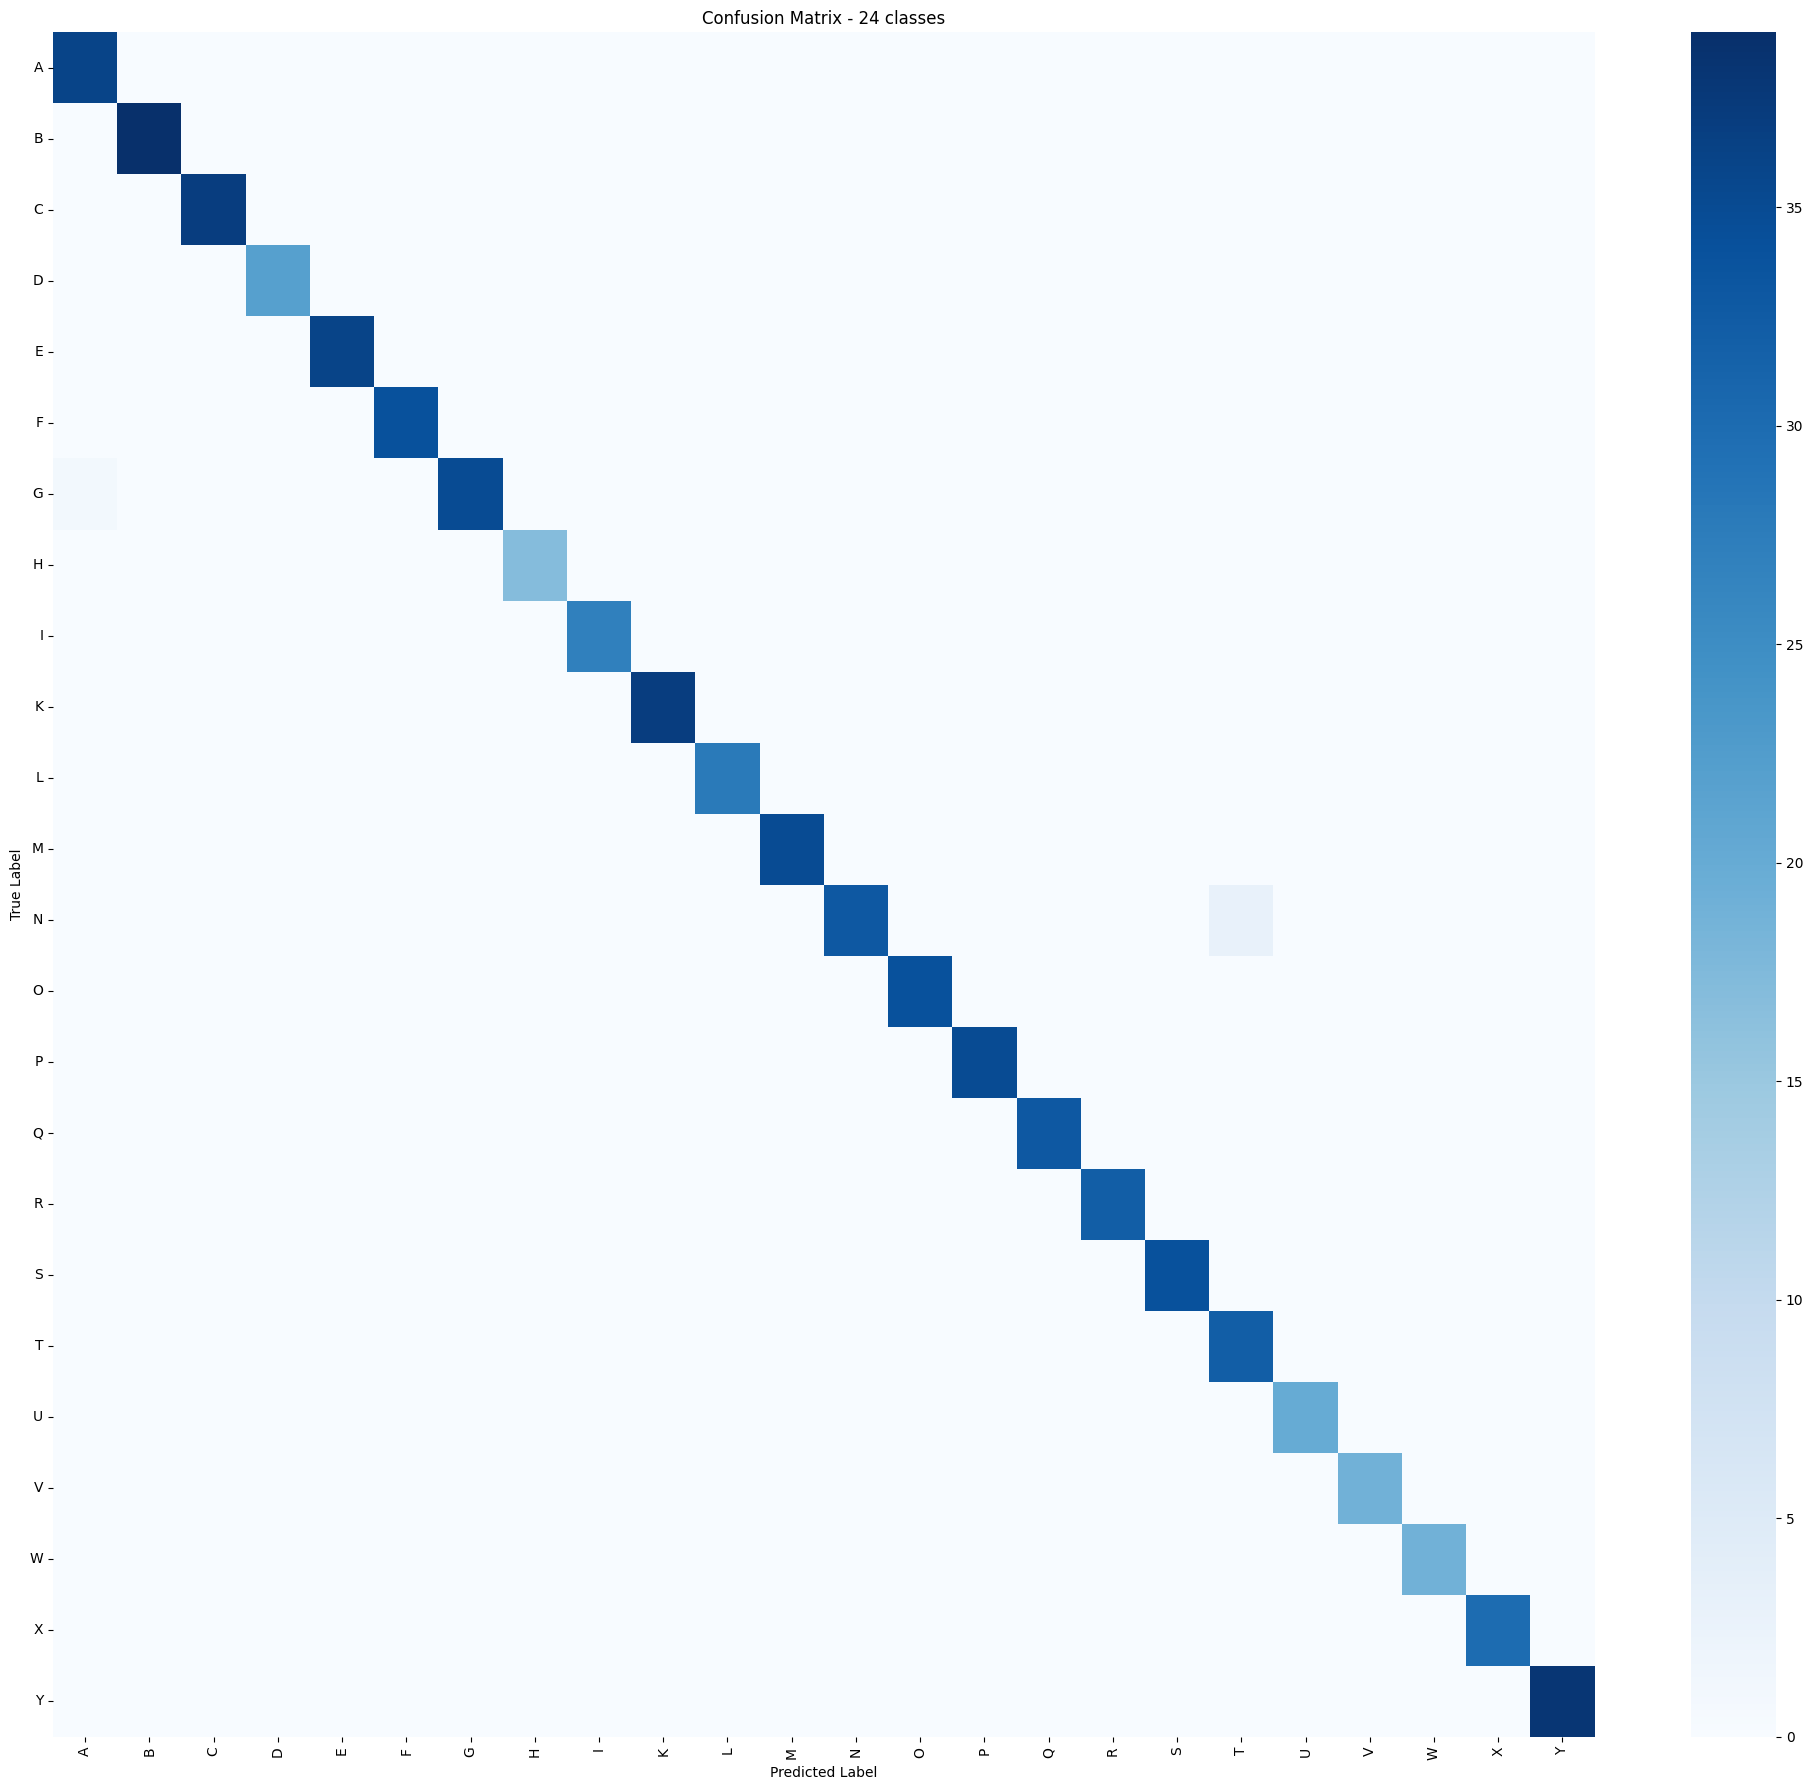

In [45]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(20, 18))
sns.heatmap(
    cm,
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - 24 classes")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

**Observation**

- Almost all the weight is on the **diagonal**.
- Only two off-diagonal cells are visible: **N predicted as T** (light) and **G predicted as A** (very faint).
- Darker diagonal cells (for example B, K, Y) are classes with more test images, and lighter ones (for example H, U, V, W) have fewer. Shade reflects image count, not accuracy.

---
## 11. Error Analysis

### 11.1 Most confused class pairs

**What it does:** Copies the confusion matrix, sets the diagonal to zero so only mistakes remain, then prints the 20 largest entries as *true class -> predicted class : count*.

**Why:** Ranks the mistakes so the most frequent confusion is easy to find.

In [46]:
cm_no_diag = cm.copy()
np.fill_diagonal(cm_no_diag, 0)

indices = np.argsort(cm_no_diag.ravel())[::-1][:20]

for idx in indices:
    true_class, pred_class = np.unravel_index(idx, cm.shape)

    print(
        f"{class_names[true_class]} → {class_names[pred_class]} : "
        f"{cm[true_class, pred_class]} images"
    )

N → T : 3 images
G → A : 1 images
I → F : 0 images
I → E : 0 images
I → D : 0 images
I → C : 0 images
I → B : 0 images
I → A : 0 images
H → Y : 0 images
H → X : 0 images
H → V : 0 images
H → U : 0 images
H → T : 0 images
H → S : 0 images
H → R : 0 images
H → Q : 0 images
H → P : 0 images
I → Y : 0 images
H → W : 0 images
I → X : 0 images


**Observation**

- Only two pairs have a non-zero count: **N -> T (3 images)** and **G -> A (1 image)**.
- The other 18 lines print 0. The list is longer than the number of real error pairs.
- Total errors: 4, which matches 742 correct out of 746.

### 11.2 Collect test images and predictions

**What it does:** Gathers all 746 test images into one array and predicts them in a single call.

**Why:** To display the wrongly predicted images themselves, not only their counts, we need the images and predictions side by side.

In [47]:
test_images = []
test_labels = []

for images, labels in test_dataset:
    test_images.extend(images.numpy())
    test_labels.extend(labels.numpy())

test_images = np.array(test_images)
test_labels = np.array(test_labels)

predictions = mobilenet_model.predict(test_images, verbose=0)
pred_labels = np.argmax(predictions, axis=1)

### 11.3 View the misclassified images

**What it does:** Finds every test image where the predicted label differs from the true label, prints how many there are, and plots up to 16 with their true and predicted letters.

**Why:** Looking at the errors shows whether they come from an ambiguous sign, a weak model, or a bad photo.

Total wrong predictions: 4


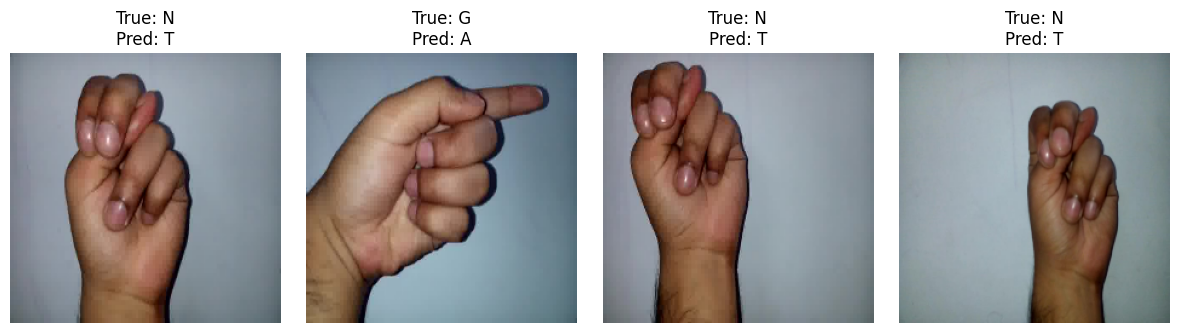

In [48]:
wrong_indices = np.where(test_labels != pred_labels)[0]

print("Total wrong predictions:", len(wrong_indices))

plt.figure(figsize=(12, 12))

for i, idx in enumerate(wrong_indices[:16]):
    plt.subplot(4, 4, i + 1)

    plt.imshow(test_images[idx].astype("uint8"))

    true_name = class_names[test_labels[idx]]
    pred_name = class_names[pred_labels[idx]]

    plt.title(f"True: {true_name}\nPred: {pred_name}")
    plt.axis("off")

plt.tight_layout()
plt.show()

**Observation**

- **4 wrong predictions** in total: three N images predicted as T, and one G image predicted as A.
- In the three N images the hand is a closed fist with curled fingers. All three were predicted as T. The same mistake repeating three times looks like a systematic N / T confusion rather than random noise.
- The G image shows the hand turned sideways with the index finger pointing out. It was predicted as A.
- All four photos are clear and well framed, so the errors do not appear to come from poor image quality.

---
## 12. Inference on a Single Image

### 12.1 Prediction function

**What it does:** `predict_class(image_path)` runs the full prediction path for one image:

1. Read the file and decode it to a tensor.
2. Resize to 224 x 224 and cast to `float32`.
3. Add a batch dimension: `(224, 224, 3)` becomes `(1, 224, 224, 3)`.
4. Run the model and take the class with the highest probability.
5. Convert that probability to a confidence percentage and the index back to a letter.
6. Show the image with the predicted letter and confidence in the title, and return both values.

**Why:** It packs the whole flow into one reusable function, close to what a deployed app would do. No extra scaling code is needed because preprocessing is already inside the model.

In [50]:
def predict_class(image_path):
    image = tf.io.read_file(image_path)
    image = tf.image.decode_image(               #converting into tensor
        image,
        channels=3,
        expand_animations=False
    )
    image = tf.image.resize(image, IMG_SIZE)
    image = tf.cast(image, tf.float32)

    image_batch = tf.expand_dims(image, axis=0)  #expanding dimension(224,22,3) -> (1,224,224,3)

    predictions = mobilenet_model.predict(image_batch, verbose=0)

    predicted_index = np.argmax(predictions[0])     #index position
    confidence = predictions[0][predicted_index] * 100          #calculating percentage
    predicted_class = class_names[predicted_index]         #coverting into class names

    plt.figure(figsize=(5, 5))
    plt.imshow(image.numpy().astype("uint8"))
    plt.title(
        f"class: {predicted_class}\n"
        f"Confidence: {confidence:.2f}%"
    )
    plt.axis("off")
    plt.show()

    return predicted_class, confidence

### 12.2 Run a prediction

**What it does:** Calls `predict_class` on `Data/D/003.jpg`.

**Why:** A simple end-to-end test of the function.

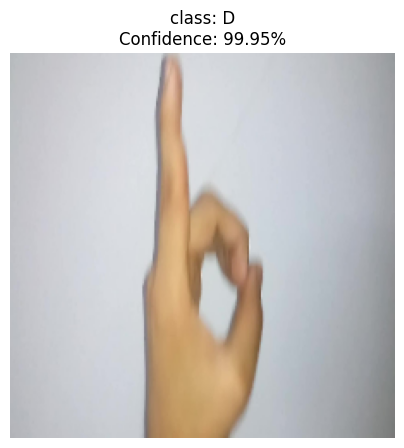

Predicted Breed: D
Confidence: 99.95%


In [51]:
image_path = "/content/indisignlang_dataset/Data/D/003.jpg"

breed, confidence = predict_class(image_path)

print("Predicted Breed:", breed)
print(f"Confidence: {confidence:.2f}%")

**Observation**

- The model predicts **D** with **99.95% confidence**, which matches the folder the image comes from.
- This image is taken from the dataset folder, and the notebook does not check whether it belongs to the training, validation or test split. Treat this as a demo of the function, not as an extra accuracy measurement.

---
## 13. Conclusion, Limitations and Next Steps

### 13.1 Summary of findings

| Area | Finding |
|---|---|
| Data | 4,972 images, 24 classes, no corrupted files. Class sizes range from 116 to 259 images. |
| Preprocessing | Images resized to 224 x 224 (originals in the sampled set range from 640 x 480 to 1920 x 1920). Stratified 70 / 15 / 15 split. |
| Model | Frozen MobileNetV2 + `Dense(256)` + `Dropout(0.3)` + `Dense(24)`. 334,104 trainable parameters. |
| Training | Early stopping at epoch 26. Best epoch 16 (validation loss 0.0109, validation accuracy 99.60%). |
| **Test result** | **99.46% accuracy, 0.0148 loss.** 4 errors out of 746: N predicted as T (3) and G predicted as A (1). |
| Small classes | H, V, W, U and D all scored 1.00 precision, recall and F1 on the test set. |
| Model size | 13.01 MB `.keras` file. |

### 13.2 Conclusion

- A MobileNetV2 transfer-learning model separates the 24 hand signs almost perfectly on this dataset: 742 of 746 test images correct.
- The validation result carried over to the test set, and the training curves show no lasting gap between training and validation.
- This was reached **without fine-tuning the backbone**. Only the new classification head was trained.
- The few remaining errors are concentrated in one repeated confusion, N predicted as T.
